In [1]:
## Tools
import numpy as np # np is short for numpy

import pandas as pd # pd is short for pandas

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns # seaborn gets shortened to sns

## Models
import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay 

# Print last updated
import datetime
print(f"Notebook last updated: {datetime.datetime.now()}\n")

# Print versions of libraries we're using
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Notebook last updated: 2026-03-02 14:35:59.943336

NumPy version: 2.3.5
pandas version: 2.3.3
matplotlib version: 3.10.6
Scikit-Learn version: 1.7.2


In [2]:
df = pd.read_csv("heart-disease-dataset/HeartDiseaseTrain-Test.csv", low_memory=False)
df.shape

(1025, 14)

In [3]:
df

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect,1
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect,0
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect,0
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect,1


In [4]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [5]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

<Axes: xlabel='target'>

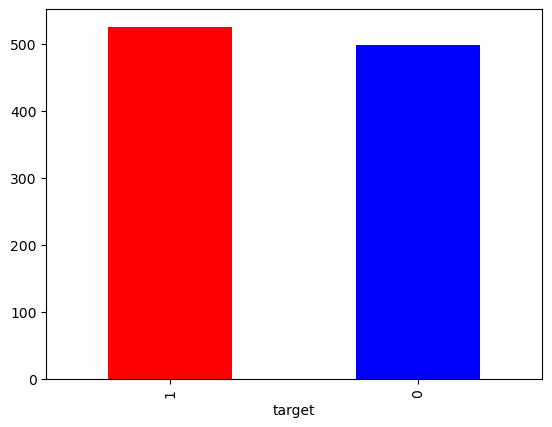

In [7]:
df["target"].value_counts().plot(kind = "bar", color = ["red", "blue"])

In [8]:
df["chest_pain_type"].value_counts()

chest_pain_type
Typical angina      497
Non-anginal pain    284
Atypical angina     167
Asymptomatic         77
Name: count, dtype: int64

<Axes: ylabel='chest_pain_type'>

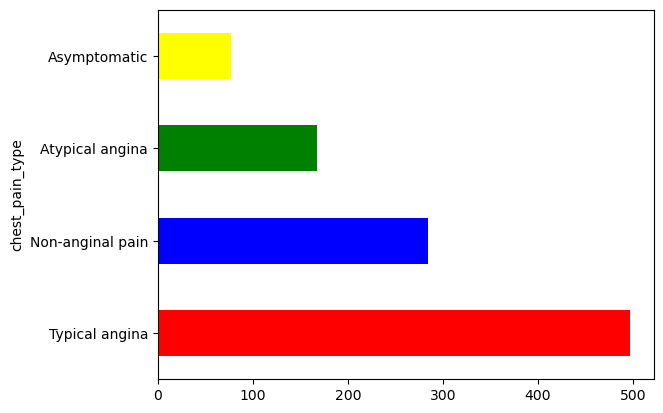

In [9]:
df["chest_pain_type"].value_counts().plot(kind = "barh", color = ["red", "blue", "green", "yellow"])

In [10]:
df["rest_ecg"].value_counts()

rest_ecg
ST-T wave abnormality           513
Normal                          497
Left ventricular hypertrophy     15
Name: count, dtype: int64

<Axes: ylabel='rest_ecg'>

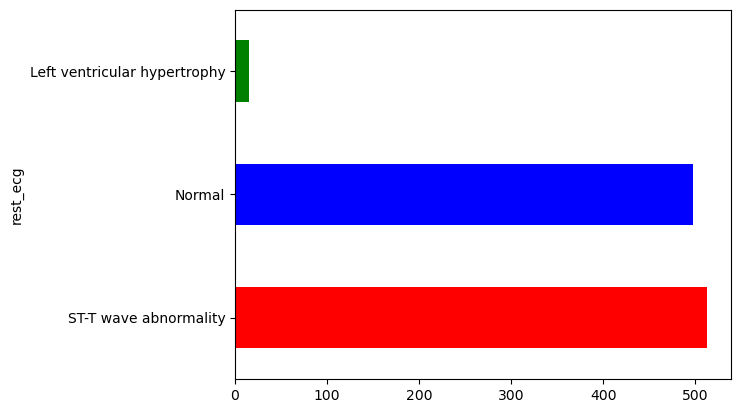

In [11]:
df["rest_ecg"].value_counts().plot(kind = "barh", color = ["red", "blue", "green"])

In [12]:
df["slope"].value_counts()

slope
Flat           482
Downsloping    469
Upsloping       74
Name: count, dtype: int64

<Axes: ylabel='slope'>

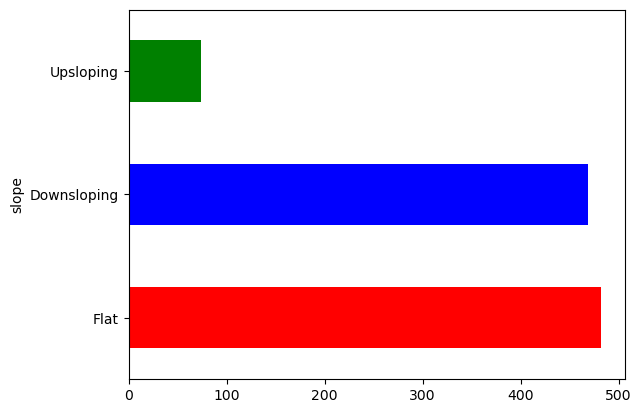

In [13]:
df["slope"].value_counts().plot(kind = "barh", color = ["red", "blue", "green"])

In [14]:
df["vessels_colored_by_flourosopy"].value_counts()

vessels_colored_by_flourosopy
Zero     578
One      226
Two      134
Three     69
Four      18
Name: count, dtype: int64

<Axes: ylabel='vessels_colored_by_flourosopy'>

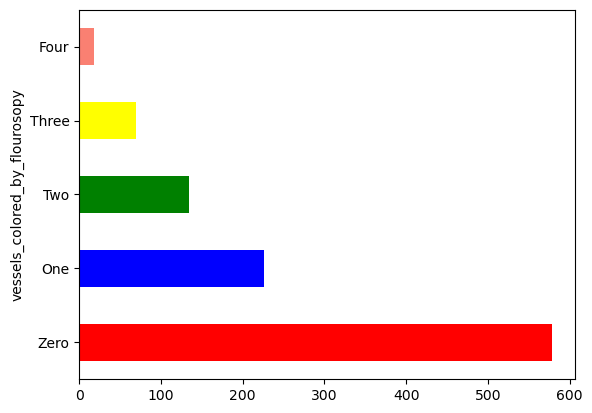

In [15]:
df["vessels_colored_by_flourosopy"].value_counts().plot(kind = "barh", color = ["red", "blue", "green", "yellow", "salmon"])

In [16]:
df["thalassemia"].value_counts()

thalassemia
Fixed Defect         544
Reversable Defect    410
Normal                64
No                     7
Name: count, dtype: int64

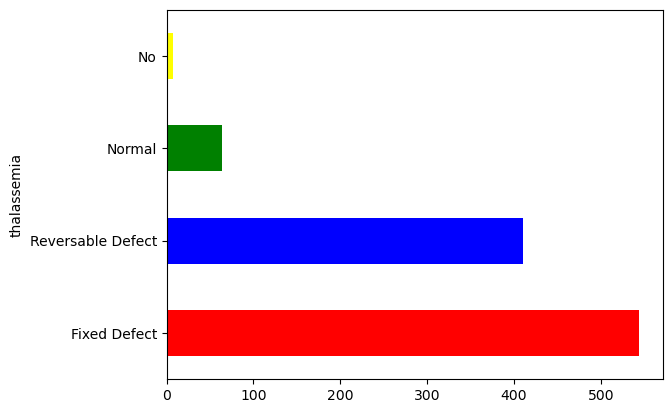

In [17]:
df["thalassemia"].value_counts().plot(kind = "barh", color = ["red", "blue", "green", "yellow"]);

In [18]:
df.isna().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [20]:
df_duplicate = df.copy()
df_duplicate

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect,1
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect,0
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect,0
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect,1


In [21]:
df_duplicate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [22]:
for label, content in df_duplicate.items():
    if pd.api.types.is_object_dtype(content):
        df_duplicate[label] = content.astype("category")


 # for label, content in df_tmp.items():
 #    if pd.api.types.is_string_dtype(content):
 #        df_tmp[label] = content.astype("category").cat.as_ordered()   

In [23]:
df_duplicate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   age                            1025 non-null   int64   
 1   sex                            1025 non-null   category
 2   chest_pain_type                1025 non-null   category
 3   resting_blood_pressure         1025 non-null   int64   
 4   cholestoral                    1025 non-null   int64   
 5   fasting_blood_sugar            1025 non-null   category
 6   rest_ecg                       1025 non-null   category
 7   Max_heart_rate                 1025 non-null   int64   
 8   exercise_induced_angina        1025 non-null   category
 9   oldpeak                        1025 non-null   float64 
 10  slope                          1025 non-null   category
 11  vessels_colored_by_flourosopy  1025 non-null   category
 12  thalassemia                    102

In [24]:
df_duplicate["chest_pain_type"].cat.categories

Index(['Asymptomatic', 'Atypical angina', 'Non-anginal pain',
       'Typical angina'],
      dtype='object')

In [25]:
df_duplicate["chest_pain_type"].cat.codes

0       3
1       3
2       3
3       3
4       3
       ..
1020    1
1021    3
1022    3
1023    3
1024    3
Length: 1025, dtype: int8

In [26]:
df_duplicate.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

In [27]:
# export preprocessed data to csv file
df_duplicate.to_csv(r".\heart-disease-dataset\heart-duplicate-converted.csv", index=False)

In [28]:
# reimport preprocessed data
df_duplicate2 = pd.read_csv("./heart-disease-dataset/heart-duplicate-converted.csv", low_memory=False)
df_duplicate2

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect,1
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect,0
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect,0
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect,1


In [29]:
df_duplicate2.isna().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

In [30]:
for label, content in df_duplicate2.items():
    if not pd.api.types.is_numeric_dtype(content):
        df_duplicate2[label] = pd.Categorical(content).codes+1

In [31]:
df_duplicate2

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,2,4,125,212,2,3,168,1,1.0,1,4,4,0
1,53,2,4,140,203,1,2,155,2,3.1,3,5,4,0
2,70,2,4,145,174,2,3,125,2,2.6,3,5,4,0
3,61,2,4,148,203,2,3,161,1,0.0,1,2,4,0
4,62,1,4,138,294,1,3,106,1,1.9,2,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,2,2,140,221,2,3,164,2,0.0,1,5,1,1
1021,60,2,4,125,258,2,2,141,2,2.8,2,2,4,0
1022,47,2,4,110,275,2,2,118,2,1.0,2,2,1,0
1023,50,1,4,110,254,2,2,159,1,0.0,1,5,1,1


In [32]:
df_duplicate2.info() # everything is now integer

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   int8   
 2   chest_pain_type                1025 non-null   int8   
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   int8   
 6   rest_ecg                       1025 non-null   int8   
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   int8   
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   int8   
 11  vessels_colored_by_flourosopy  1025 non-null   int8   
 12  thalassemia                    1025 non-null   i

In [33]:
# comparing some features with our target column
pd.crosstab(index = df_duplicate2["chest_pain_type"], columns = df_duplicate2["target"])

target,0,1
chest_pain_type,,
1,26,51
2,33,134
3,65,219
4,375,122


In [34]:
pd.crosstab(index = df["chest_pain_type"], columns = df["target"])

target,0,1
chest_pain_type,,
Asymptomatic,26,51
Atypical angina,33,134
Non-anginal pain,65,219
Typical angina,375,122


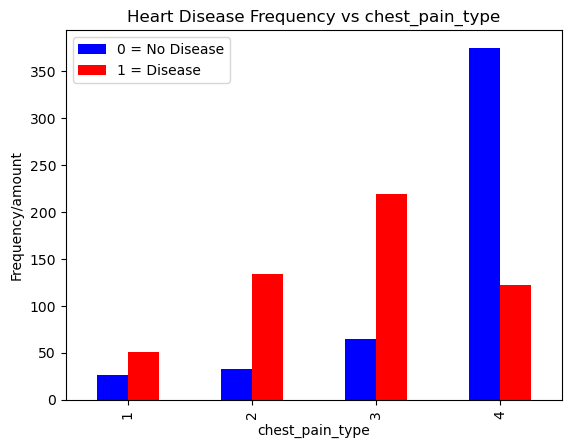

In [35]:
# visualizing them
pd.crosstab(index = df_duplicate2["chest_pain_type"], columns = df_duplicate2["target"]).plot(kind = "bar", color = ["blue", "red"])
plt.title("Heart Disease Frequency vs chest_pain_type")
plt.xlabel("chest_pain_type")
plt.ylabel("Frequency/amount")
plt.legend(["0 = No Disease", "1 = Disease"]);

In [36]:
pd.crosstab(index = df_duplicate2["slope"], columns = df_duplicate2["target"])

target,0,1
slope,,
1,129,340
2,324,158
3,46,28


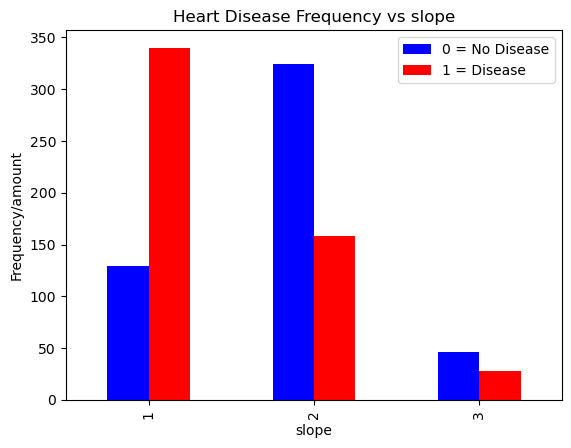

In [37]:
pd.crosstab(index = df_duplicate2["slope"], columns = df_duplicate2["target"]).plot(kind = "bar", color = ["blue", "red"])
plt.title("Heart Disease Frequency vs slope")
plt.xlabel("slope")
plt.ylabel("Frequency/amount")
plt.legend(["0 = No Disease", "1 = Disease"]);

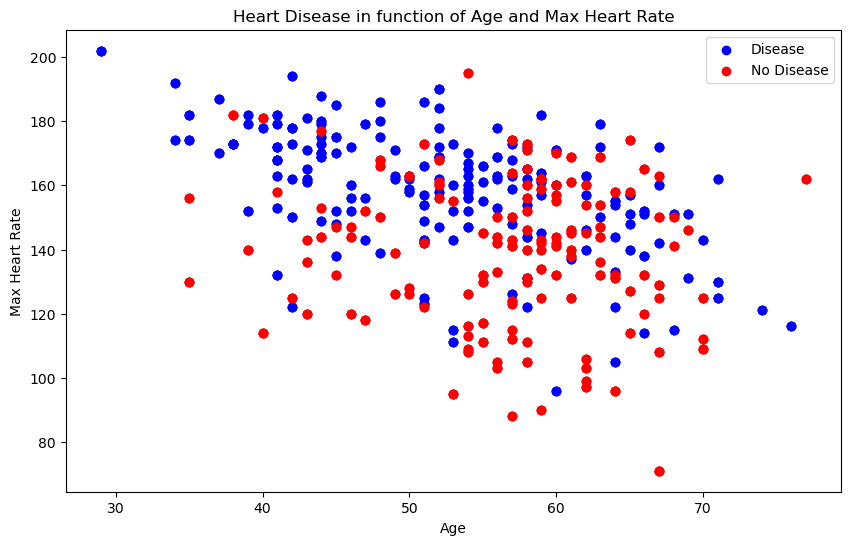

In [38]:
# lets compare age and max heart rate
plt.figure(figsize=(10, 6))

plt.scatter(df_duplicate2.age[df_duplicate2.target == 1],
            df_duplicate2.Max_heart_rate[df_duplicate2.target == 1],
            c = "blue")

plt.scatter(df_duplicate2.age[df_duplicate2.target == 0],
            df_duplicate2.Max_heart_rate[df_duplicate2.target == 0],
            c = "red")


plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.legend(["Disease", "No Disease"])
plt.ylabel("Max Heart Rate");

In [39]:
df_duplicate2

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,2,4,125,212,2,3,168,1,1.0,1,4,4,0
1,53,2,4,140,203,1,2,155,2,3.1,3,5,4,0
2,70,2,4,145,174,2,3,125,2,2.6,3,5,4,0
3,61,2,4,148,203,2,3,161,1,0.0,1,2,4,0
4,62,1,4,138,294,1,3,106,1,1.9,2,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,2,2,140,221,2,3,164,2,0.0,1,5,1,1
1021,60,2,4,125,258,2,2,141,2,2.8,2,2,4,0
1022,47,2,4,110,275,2,2,118,2,1.0,2,2,1,0
1023,50,1,4,110,254,2,2,159,1,0.0,1,5,1,1


In [40]:
# modelling
x = df_duplicate2.drop(labels = "target", axis = 1)
y = df_duplicate2["target"].to_numpy()

In [41]:
x

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
0,52,2,4,125,212,2,3,168,1,1.0,1,4,4
1,53,2,4,140,203,1,2,155,2,3.1,3,5,4
2,70,2,4,145,174,2,3,125,2,2.6,3,5,4
3,61,2,4,148,203,2,3,161,1,0.0,1,2,4
4,62,1,4,138,294,1,3,106,1,1.9,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,2,2,140,221,2,3,164,2,0.0,1,5,1
1021,60,2,4,125,258,2,2,141,2,2.8,2,2,4
1022,47,2,4,110,275,2,2,118,2,1.0,2,2,1
1023,50,1,4,110,254,2,2,159,1,0.0,1,5,1


In [42]:
y, type(y)

(array([0, 0, 0, ..., 0, 1, 0], shape=(1025,)), numpy.ndarray)

In [43]:
np.random.seed(42)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [44]:
len(x_train), len(x_test), len(y_train), len(y_test)

(820, 205, 820, 205)

In [45]:
models = {"Logistics Regression": LogisticRegression(),
          "SVC": SVC(),
          "GaussianNB": GaussianNB(),
          "SDCClassifier": SGDClassifier(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

# Creating function to fit and score models
def model_fit_and_score(models, x_train, x_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data
    X_test : testing data
    y_train : labels assosciated with training data
    y_test : labels assosciated with test data
    """

    np.random.seed(42)

    models_score = {}

    for name, model in models.items():
        model.fit(x_train, y_train)
        models_score[name] = model.score(x_test, y_test)
    return models_score

In [46]:
models_score = model_fit_and_score(models, x_train, x_test, y_train, y_test)
models_score

C:\Users\adeku\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistics Regression': 0.7853658536585366,
 'SVC': 0.6780487804878049,
 'GaussianNB': 0.775609756097561,
 'SDCClassifier': 0.6097560975609756,
 'KNN': 0.7317073170731707,
 'Random Forest': 0.9853658536585366}

In [47]:
# lets compare and visualize the models
model_compare = pd.DataFrame(models_score, index = ["accuracy"])
model_compare

,Logistics Regression,SVC,GaussianNB,SDCClassifier,KNN,Random Forest
accuracy,0.785366,0.678049,0.77561,0.609756,0.731707,0.985366


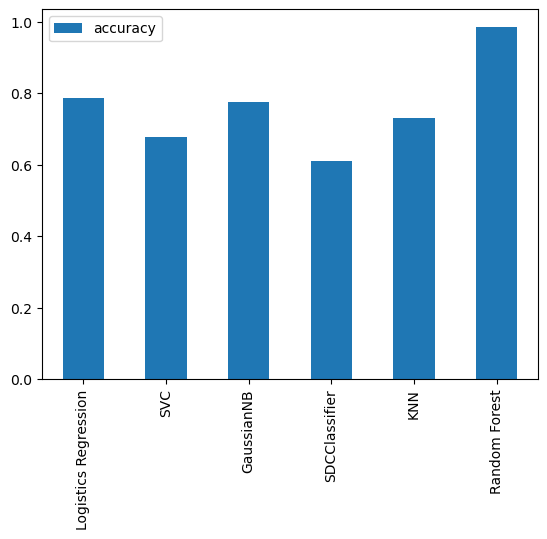

In [48]:
model_compare.T.plot.bar();

In [49]:
#Tunning our selected models with RandomsearchCV
# we are tuning logistic regression and random forest
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear", "lbfgs"]}
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2),
           "max_features":["sqrt", "log2", None]}

In [50]:
%%time
# tuning for logistic regression

np.random.seed(42)

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Fit random hyperparameter search model
rs_log_reg.fit(x_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\adeku\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\adeku\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re

CPU times: total: 7.61 s
Wall time: 4.8 s


C:\Users\adeku\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(29.763514416313132)}

In [52]:
rs_log_reg.score(x_test, y_test)

0.7951219512195122

In [53]:
%%time 
# tuning random forest classifier
np.random.seed(42)

rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

rs_rf.fit(x_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: total: 2min 33s
Wall time: 3min 12s


In [54]:
rs_rf.best_params_

{'n_estimators': np.int64(160),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(1),
 'max_features': None,
 'max_depth': 5}

In [55]:
rs_rf.score(x_test, y_test)

0.8780487804878049

In [56]:
%%time

# now tuning our model further with gridsearchcv
# for logistic regression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear", "lbfgs"]}
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

gs_log_reg.fit(x_train, y_train);

Fitting 5 folds for each of 40 candidates, totalling 200 fits


C:\Users\adeku\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\adeku\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re

CPU times: total: 12.6 s
Wall time: 9.3 s


In [57]:
gs_log_reg.best_params_

{'C': np.float64(29.763514416313132), 'solver': 'liblinear'}

In [58]:
gs_log_reg.score(x_test, y_test)

0.7951219512195122

In [59]:
%%time

# for randomforest classifier
rf_grid = {"n_estimators": [100, 200, 500, 1000],
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": [2, 4],
           "min_samples_leaf": [1, 2],
           "max_features":["sqrt", "log2", None]}

gs_rf = GridSearchCV(RandomForestClassifier(),
                           param_grid=rf_grid,
                           cv=5,
                           verbose=True)

gs_rf.fit(x_train, y_train);

Fitting 5 folds for each of 192 candidates, totalling 960 fits
CPU times: total: 26min 14s
Wall time: 32min 10s


In [60]:
gs_rf.best_params_

{'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [61]:
gs_rf.score(x_test, y_test)

0.9853658536585366

In [62]:
y_preds = gs_rf.predict(x_test)
y_preds

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])

In [63]:
y_test

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])

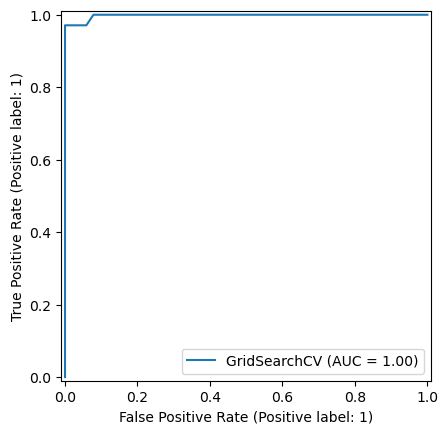

In [64]:
RocCurveDisplay.from_estimator(gs_rf, x_test, y_test);

In [65]:
conf_matrix = confusion_matrix(y_test, y_preds)
conf_matrix

array([[102,   0],
       [  3, 100]])

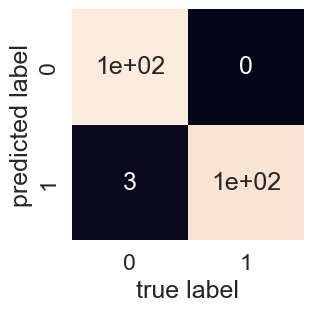

In [66]:
sns.set(font_scale=1.5) # Increase font size

def plot_conf_matrix(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("true label")
    plt.ylabel("predicted label")
    
plot_conf_matrix(y_test, y_preds);

In [67]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [68]:
gs_rf.best_params_

{'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [69]:
clf = RandomForestClassifier(max_depth= None,
                             max_features= None,
                             min_samples_leaf= 1,
                             min_samples_split= 2,
                             n_estimators= 100)

In [70]:
# Cross-validated accuracy score
cv_acc = cross_val_score(clf,
                         x,
                         y,
                         cv=5,
                         scoring="accuracy") 
cv_acc

array([1.        , 1.        , 1.        , 1.        , 0.98536585])

In [71]:
cv_acc2 = np.mean(cv_acc)
cv_acc2

np.float64(0.9970731707317073)

In [72]:
cv_precision = cross_val_score(clf,
                         x,
                         y,
                         cv=5,
                         scoring="precision") 
cv_precision

array([1.        , 1.        , 1.        , 1.        , 0.97247706])

In [73]:
cv_precision2 = np.mean(cv_precision)
cv_precision2

np.float64(0.9944954128440366)

In [74]:
cv_recall = cross_val_score(clf,
                         x,
                         y,
                         cv=5,
                         scoring="recall") 
cv_recall

array([1.        , 1.        , 1.        , 0.97142857, 1.        ])

In [75]:
cv_recall2 = np.mean(cv_recall)
cv_recall2

np.float64(0.9942857142857143)

In [76]:
cv_f1 = cross_val_score(clf,
                         x,
                         y,
                         cv=5,
                         scoring="f1") 
cv_f1

array([1.        , 1.        , 1.        , 0.98550725, 0.98604651])

In [77]:
cv_f12 = np.mean(cv_f1)
cv_f12

np.float64(0.9943107516009437)

In [78]:
# lets visualize our cross validated metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_acc2,
                            "Precision": cv_precision2,
                            "Recall": cv_recall2,
                            "F1": cv_f12},
                          index=[0])
cv_metrics

,Accuracy,Precision,Recall,F1
0,0.997073,0.994495,0.994286,0.994311


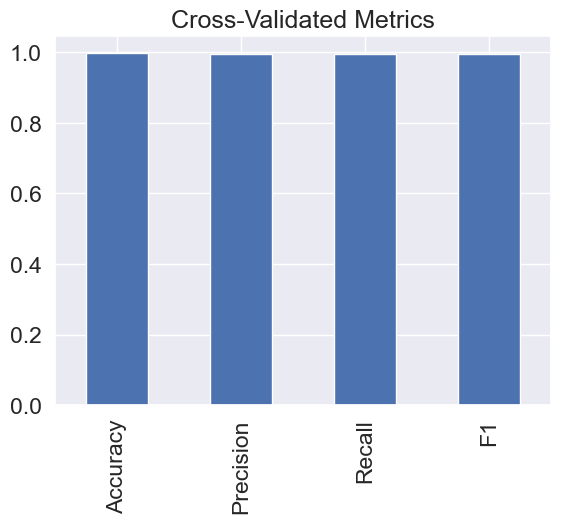

In [79]:
cv_metrics.T.plot.bar(title="Cross-Validated Metrics", legend=False);

## Feature importance

In [80]:
# We access the coef_ attribute after we've fit an instance of Randomforestclassifier().
clf.fit(x_train, y_train);

In [81]:
clf.feature_importances_

array([0.08015044, 0.01554139, 0.19479978, 0.05880613, 0.09532099,
       0.00507178, 0.00909631, 0.07065405, 0.01125791, 0.10225234,
       0.02645789, 0.11852563, 0.21206536])

In [82]:
# Match features to columns
features_dict = dict(zip(df.columns, list(clf.feature_importances_)))
features_dict

{'age': np.float64(0.08015043841092578),
 'sex': np.float64(0.015541394048360312),
 'chest_pain_type': np.float64(0.19479977697923348),
 'resting_blood_pressure': np.float64(0.05880613160373401),
 'cholestoral': np.float64(0.09532099051714069),
 'fasting_blood_sugar': np.float64(0.005071779159579944),
 'rest_ecg': np.float64(0.009096305809820283),
 'Max_heart_rate': np.float64(0.07065405142521625),
 'exercise_induced_angina': np.float64(0.011257914944211894),
 'oldpeak': np.float64(0.10225233822782002),
 'slope': np.float64(0.026457886241998633),
 'vessels_colored_by_flourosopy': np.float64(0.11852563300176054),
 'thalassemia': np.float64(0.2120653596301981)}

In [83]:
# put in a dataframe
features_df = pd.DataFrame(features_dict, index=[0])
features_df

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
0,0.08015,0.015541,0.1948,0.058806,0.095321,0.005072,0.009096,0.070654,0.011258,0.102252,0.026458,0.118526,0.212065


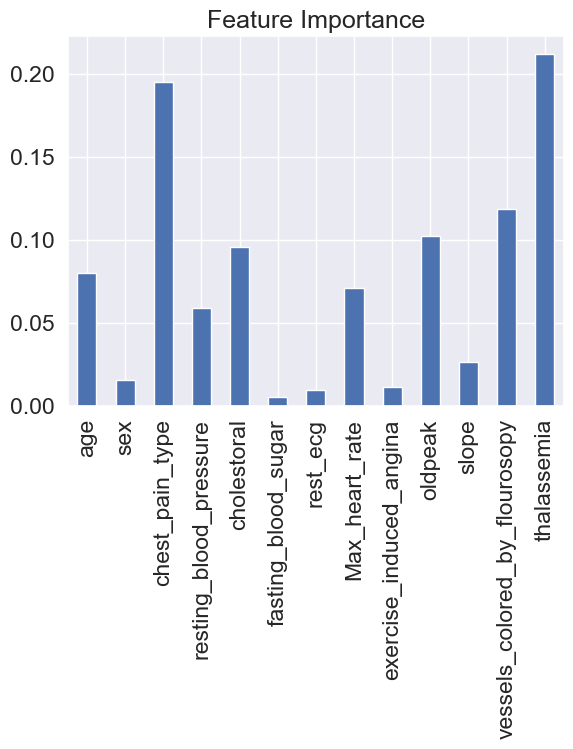

In [84]:
# visualizing the dataframe
features_df.T.plot.bar(title="Feature Importance", legend=False);